In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [2]:
np.random.seed(10)

rows = 3000

data = pd.DataFrame({

"revenue":np.random.randint(1000,50000,rows),
"expenses":np.random.randint(500,30000,rows),
"assets":np.random.randint(5000,100000,rows),
"liabilities":np.random.randint(1000,80000,rows),
"employee_cost":np.random.randint(1000,20000,rows),
"tax_paid":np.random.randint(500,10000,rows)

})

data["profit"] = data["revenue"] - data["expenses"] - data["employee_cost"]

data["cash_flow"] = data["revenue"] - data["expenses"]

print(data.head())

   revenue  expenses  assets  liabilities  employee_cost  tax_paid  profit  \
0    18673     18796   10263        71410          16262       534  -16385   
1    41061     15229   46420        22954           9298      9842   16534   
2    30199      8378   25303        47528          19947      8652    1874   
3    29017      7839   84957        17124          16710      1034    4468   
4    41059      5081   28291         5659           6870      4034   29108   

   cash_flow  
0       -123  
1      25832  
2      21821  
3      21178  
4      35978  


In [3]:
X = data.drop(["profit"],axis=1)

y = data["profit"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestRegressor()

model.fit(X_train,y_train)

prediction = model.predict(X_test)

print("Prediction Sample:",prediction[:5])

Prediction Sample: [-37024.39 -29291.67 -21209.86   5670.71  -3792.05]


In [5]:
sample = pd.DataFrame({

"revenue":[20000],
"expenses":[10000],
"assets":[60000],
"liabilities":[20000],
"employee_cost":[8000],
"tax_paid":[3000],
"cash_flow":[10000]

})

predicted_profit = model.predict(sample)

print("Predicted Profit:",predicted_profit[0])


Predicted Profit: 1877.03


In [6]:
def generate_report(revenue,expenses,profit):

    report = f"""

LORD MURUGAN ACCOUNTS
AI FINANCIAL REPORT

Revenue : {revenue}
Expenses : {expenses}
Predicted Profit : {profit}

AI Analysis:
The system analyzed accounting data and generated
financial insights.

Recommendation:
• Increase revenue sources
• Reduce operational expenses
• Improve financial planning

"""

    return report


print(generate_report(20000,10000,predicted_profit[0]))




LORD MURUGAN ACCOUNTS
AI FINANCIAL REPORT

Revenue : 20000
Expenses : 10000
Predicted Profit : 1877.03

AI Analysis:
The system analyzed accounting data and generated
financial insights.

Recommendation:
• Increase revenue sources
• Reduce operational expenses
• Improve financial planning




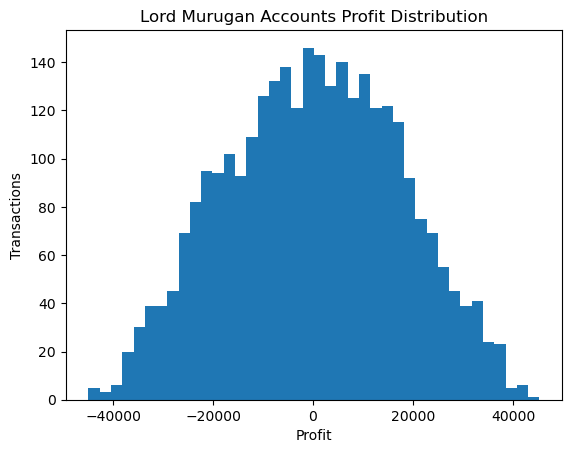

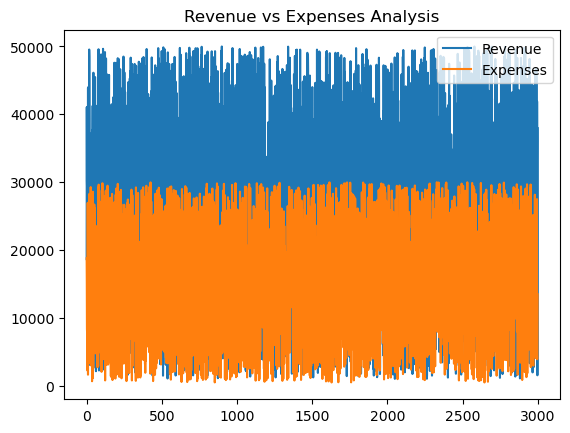

In [7]:
plt.hist(data["profit"],bins=40)

plt.title("Lord Murugan Accounts Profit Distribution")

plt.xlabel("Profit")

plt.ylabel("Transactions")

plt.show()


plt.plot(data["revenue"],label="Revenue")
plt.plot(data["expenses"],label="Expenses")

plt.legend()

plt.title("Revenue vs Expenses Analysis")

plt.show()

In [8]:
data.to_csv("lord_murugan_accounts_dataset.csv",index=False)

print("Dataset saved successfully")

Dataset saved successfully


In [10]:
os.makedirs("templates",exist_ok=True)
os.makedirs("static",exist_ok=True)

html = """

<!DOCTYPE html>
<html>

<head>

<title>Lord Murugan Accounts</title>

<link rel="stylesheet" href="/static/style.css">

</head>

<body>

<h1>Lord Murugan Accounts</h1>

<h2>AI Powered Accounting Platform</h2>

<form action="/predict" method="post">

<input name="revenue" placeholder="Revenue"><br>

<input name="expenses" placeholder="Expenses"><br>

<input name="assets" placeholder="Assets"><br>

<input name="liabilities" placeholder="Liabilities"><br>

<input name="employee_cost" placeholder="Employee Cost"><br>

<input name="tax_paid" placeholder="Tax Paid"><br>

<button type="submit">Predict Profit</button>

</form>

</body>

</html>

"""

open("templates/index.html","w").write(html)


css = """

body{

text-align:center;
font-family:Arial;
background:#f2f2f2;

}

h1{

color:green;

}

input{

padding:10px;
margin:5px;

}

button{

padding:10px;
background:green;
color:white;

}

"""

open("static/style.css","w").write(css)

flask_code = """

from flask import Flask,render_template,request
import pandas as pd
import numpy as np
import pickle

app = Flask(__name__)

model = pickle.load(open("model.pkl","rb"))

@app.route("/")
def home():

    return render_template("index.html")

@app.route("/predict",methods=["POST"])

def predict():

    revenue = float(request.form["revenue"])
    expenses = float(request.form["expenses"])
    assets = float(request.form["assets"])
    liabilities = float(request.form["liabilities"])
    employee_cost = float(request.form["employee_cost"])
    tax_paid = float(request.form["tax_paid"])

    cash_flow = revenue - expenses

    sample = pd.DataFrame({

    "revenue":[revenue],
    "expenses":[expenses],
    "assets":[assets],
    "liabilities":[liabilities],
    "employee_cost":[employee_cost],
    "tax_paid":[tax_paid],
    "cash_flow":[cash_flow]

    })

    prediction = model.predict(sample)[0]

    return f"Predicted Profit: {prediction}"

if __name__ == "__main__":
    app.run()

"""

open("app.py","w").write(flask_code)

import pickle

pickle.dump(model,open("model.pkl","wb"))

print("Website + AI Model Ready")
print("Run: python app.py")

Website + AI Model Ready
Run: python app.py
